# Практика: Снижение размерности — PCA, t-SNE и UMAP

## Что вы сделаете
В этом ноутбуке вы:

1. загрузите и исследуете датасет `digits` (рукописные цифры);
2. примените **PCA** как препроцессинг: выберете число компонент по cumulative EVR;
3. проинтерпретируете главные компоненты через **loadings**;
4. обучите классификатор на PCA-признаках и сравните с обучением на исходных признаках;
5. визуализируете структуру данных через **t-SNE** и **UMAP**;
6. сравните 2D-проекции PCA, t-SNE и UMAP: насколько хорошо разделяются классы?
7. (Автор, логичнее было бы **t-SNE** и **UMAP** применять во время **EDA**, не находишь?)

## Датасет
Мы используем `digits` из `sklearn.datasets`:
- 1797 изображений рукописных цифр 0–9;
- каждое изображение — 8×8 пикселей = **64 признака** (интенсивность пикселей);
- задача: 10-классовая классификация.

## Что сдавать
1. Заполненный ноутбук со всем кодом.
2. Краткие выводы в конце:
   - сколько компонент PCA достаточно для сохранения 95% дисперсии?
   - как влияет PCA-препроцессинг на качество классификатора?
   - какой метод визуализации (PCA, t-SNE, UMAP) лучше разделяет классы?

---
## Шаг 1. Загрузка и первичный анализ данных

In [23]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.datasets import load_digits
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

digits = load_digits()
X = digits.data
y = digits.target

print(f"Форма X: {X.shape}")
print(f"Классы: {np.unique(y)}")
print(f"Признаки: {X.shape[1]} (8x8 пикселей)")

Форма X: (1797, 64)
Классы: [0 1 2 3 4 5 6 7 8 9]
Признаки: 64 (8x8 пикселей)


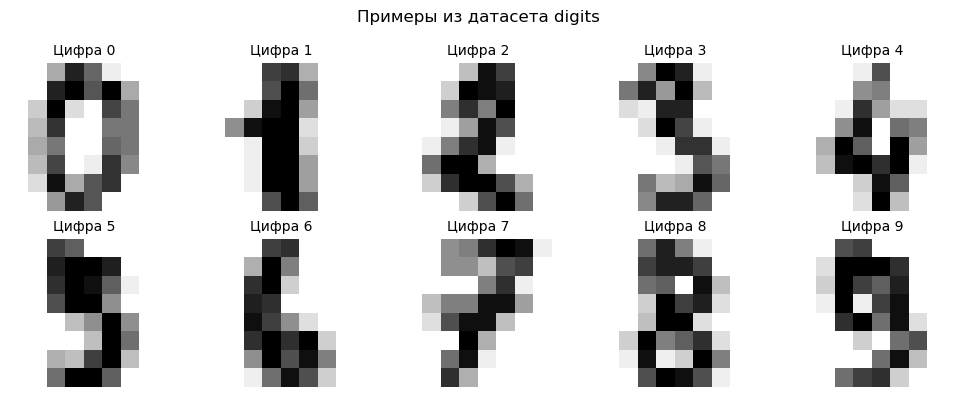

In [2]:
# Визуализируем примеры из каждого класса
fig, axes = plt.subplots(2, 5, figsize=(10, 4))
for ax, idx in zip(axes.flat, range(10)):
    sample_idx = np.where(y == idx)[0][0]
    ax.imshow(X[sample_idx].reshape(8, 8), cmap='gray_r')
    ax.set_title(f'Цифра {idx}', fontsize=10)
    ax.axis('off')
plt.suptitle('Примеры из датасета digits', fontsize=12)
plt.tight_layout()
plt.show()

In [3]:
# Стандартизация — обязательный шаг перед PCA!
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print(f"Среднее до: {X.mean():.2f}, после: {X_scaled.mean():.4f}")
print(f"Std до: {X.std():.2f}, после: {X_scaled.std():.4f}")

Среднее до: 4.88, после: 0.0000
Std до: 6.02, после: 0.9763


---
## Шаг 2. PCA: explained variance и выбор числа компонент

Обучите PCA на всех 64 компонентах. Постройте график накопленной объясняемой дисперсии.
Определите, сколько компонент нужно для сохранения 80%, 95% и 99% дисперсии.

In [4]:
PCA?

Init signature:
PCA(
    n_components=None,
    *,
    copy=True,
    whiten=False,
    svd_solver='auto',
    tol=0.0,
    iterated_power='auto',
    n_oversamples=10,
    power_iteration_normalizer='auto',
    random_state=None,
)
Docstring:     
Principal component analysis (PCA).

Linear dimensionality reduction using Singular Value Decomposition of the
data to project it to a lower dimensional space. The input data is centered
but not scaled for each feature before applying the SVD.

It uses the LAPACK implementation of the full SVD or a randomized truncated
SVD by the method of Halko et al. 2009, depending on the shape of the input
data and the number of components to extract.

With sparse inputs, the ARPACK implementation of the truncated SVD can be
used (i.e. through :func:`scipy.sparse.linalg.svds`). Alternatively, one
may consider :class:`TruncatedSVD` where the data are not centered.

Notice that this class only supports sparse inputs for some solvers such as
"arpack" and "c

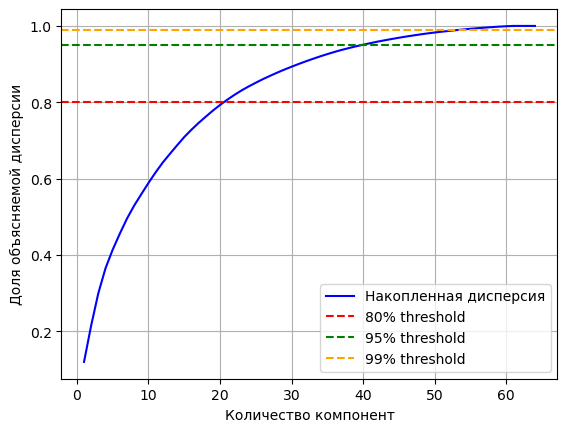

80% дисперсии -> 21 компонент
95% дисперсии -> 40 компонент
99% дисперсии -> 54 компонент


In [5]:
# Обучите PCA на всех компонентах
pca_full = PCA(n_components=64, random_state=42)
# YOUR CODE HERE
pca_full.fit(X_scaled)


# Вычислите накопленную объясняемую дисперсию
def nacop_sum(step):
    sum = 0
    for i in range(step):
        sum += pca_full.explained_variance_ratio_[i]
    return sum
cumvar = []
for i in range(1, 65):
    cumvar.append(nacop_sum(i))
# YOUR CODE HERE

# Постройте график: по оси X — число компонент, по оси Y — cumvar
# Добавьте горизонтальные линии для 80%, 95%, 99%
# YOUR CODE HERE
import matplotlib.pyplot as plt

# По оси X — число компонент (от 1 до 64), по оси Y — наш cumvar
plt.plot(range(1, 65), cumvar, label='Накопленная дисперсия', color='blue')

# Добавляем горизонтальные линии для порогов
plt.axhline(y=0.80, color='red', linestyle='--', label='80% threshold')
plt.axhline(y=0.95, color='green', linestyle='--', label='95% threshold')
plt.axhline(y=0.99, color='orange', linestyle='--', label='99% threshold')

plt.xlabel('Количество компонент')
plt.ylabel('Доля объясняемой дисперсии')
plt.legend()
plt.grid(True)
plt.show()

def to_find_k(arr, explained_var):
    for i in range(len(arr)):
        if explained_var <= arr[i]:
            return i+1
# Найдите минимальное k для каждого порога
for threshold in [0.80, 0.95, 0.99]:
    k = to_find_k(cumvar, threshold)
    print(f"{int(threshold*100)}% дисперсии -> {k} компонент")

---
## Шаг 3. PCA для визуализации (2 компоненты)

Спроецируйте данные на 2 главных компоненты. Визуализируйте scatter plot с раскраской по классу.
Укажите долю объяснённой дисперсии на осях.

PC1: 12.0%
PC2: 9.6%
Итого: 21.6%


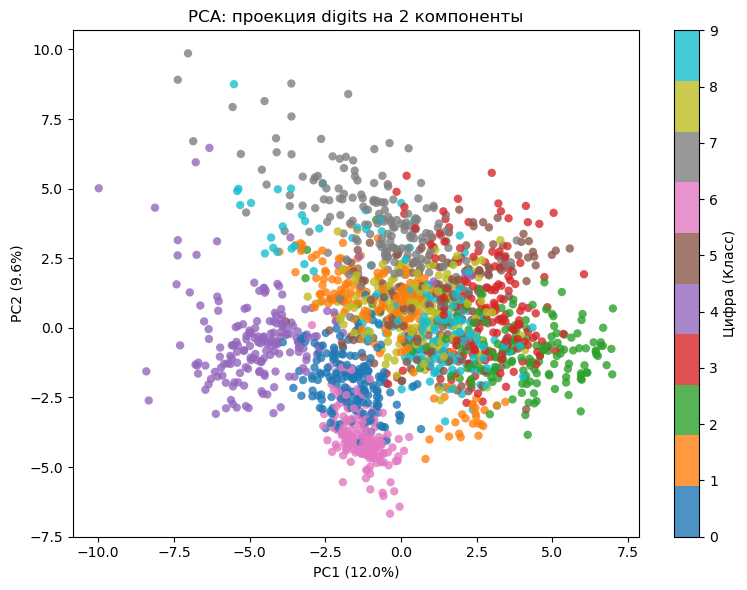

In [6]:
pca2 = PCA(n_components=2, random_state=42)
X_pca2 = pca2.fit_transform(X_scaled)
# YOUR CODE HERE

print(f"PC1: {pca2.explained_variance_ratio_[0]*100:.1f}%")
print(f"PC2: {pca2.explained_variance_ratio_[1]*100:.1f}%")
print(f"Итого: {pca2.explained_variance_ratio_.sum()*100:.1f}%")

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_pca2[:, 0], X_pca2[:, 1], c=digits.target, cmap='tab10', alpha=0.8, edgecolors='none')
plt.colorbar(scatter, ticks=range(10), label='Цифра (Класс)')


# YOUR CODE HERE: scatter с cmap='tab10', colorbar
plt.xlabel(f'PC1 ({pca2.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'PC2 ({pca2.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('PCA: проекция digits на 2 компоненты')
plt.tight_layout()
plt.show()

---
## Шаг 4. Интерпретация: loadings (нагрузки)

Visualizируйте нагрузки PC1 и PC2 как 8×8 изображения.
Яркие пиксели = сильное влияние на данную компоненту.
Используйте diverging colormap `'RdBu_r'`.

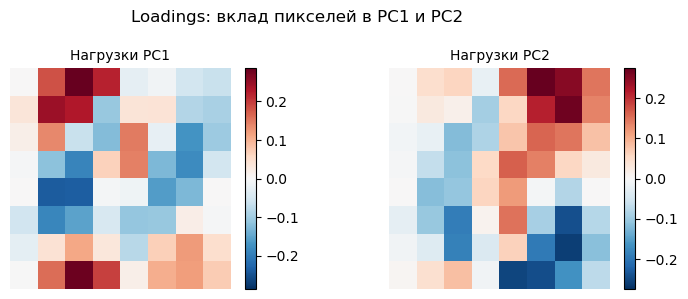

In [7]:
# pca2.components_ имеет форму (2, 64)
fig, axes = plt.subplots(1, 2, figsize=(8, 3))
for i, ax in enumerate(axes):
    # 1. Берем i-ю строку (64 числа) и превращаем в картинку 8x8
    loadings_matrix = pca2.components_[i].reshape(8, 8)
    
    # 2. Рисуем тепловую карту с дивергирующей палитрой
    # vmin и vmax делают шкалу симметричной, чтобы 0 был строго белым
    max_val = abs(loadings_matrix).max()
    im = ax.imshow(loadings_matrix, cmap='RdBu_r', vmin=-max_val, vmax=max_val)
    
    # 3. Добавляем маленькую шкалу весов к каждому графику
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    
    ax.set_title(f'Нагрузки PC{i+1}', fontsize=10)
    ax.axis('off')

plt.suptitle('Loadings: вклад пикселей в PC1 и PC2', fontsize=12)
plt.tight_layout()
plt.show()


---
## Шаг 5. PCA как препроцессинг для классификатора

Сравните качество LogisticRegression:
1. На исходных 64 признаках
2. На PCA 95% дисперсии
3. На PCA 80% дисперсии

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

results = {}

# --- Вариант 1: без PCA ---
clf_base = LogisticRegression(max_iter=1000, random_state=42)
# YOUR CODE HERE
clf_base.fit(X_train, y_train)
preds_clf_base = clf_base.predict(X_test)
results['Без PCA (64 признака)'] = accuracy_score(y_test, preds_clf_base)
# YOUR CODE HERE

# --- Вариант 2: PCA с 95% дисперсии ---
# Подсказка: PCA(n_components=0.95) автоматически выбирает k
pca_95 = PCA(n_components=0.95, random_state=42)
X_train_95 = pca_95.fit_transform(X_train)
X_test_95  = pca_95.transform(X_test)
clf_95 = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_95, y_train)
preds_95_explained_varience = clf_95.predict(X_test_95)
# YOUR CODE HERE
results[f'PCA 95% ({pca_95.n_components_} компонент)'] = accuracy_score(y_test, preds_95_explained_varience) 
# YOUR CODE HERE

# --- Вариант 3: PCA с 80% дисперсии ---
pca_80 = PCA(n_components=0.80, random_state=42)
# YOUR CODE HERE
X_train_80 = pca_80.fit_transform(X_train)
X_test_80 = pca_80.transform(X_test)
clf_80 = LogisticRegression(max_iter=1000, random_state=42).fit(X_train_80, y_train)
preds_80_explained_varience = clf_80.predict(X_test_80)
results[f'PCA 80% ({pca_80.n_components_} компонент)'] = accuracy_score(y_test, preds_80_explained_varience)
# YOUR CODE HERE

print("Сравнение accuracy:")
print("-" * 45)
for name, acc in results.items():
    print(f"{name:35s}: {acc:.4f}")

Сравнение accuracy:
---------------------------------------------
Без PCA (64 признака)              : 0.9722
PCA 95% (40 компонент)             : 0.9639
PCA 80% (21 компонент)             : 0.9472


---
## Шаг 6. t-SNE: нелинейная визуализация

Рекомендуемый пайплайн: сначала PCA до 30 компонент, затем t-SNE. Это ускоряет работу и убирает шум.

In [21]:
TSNE?

Init signature:
TSNE(
    n_components=2,
    *,
    perplexity=30.0,
    early_exaggeration=12.0,
    learning_rate='auto',
    max_iter=1000,
    n_iter_without_progress=300,
    min_grad_norm=1e-07,
    metric='euclidean',
    metric_params=None,
    init='pca',
    verbose=0,
    random_state=None,
    method='barnes_hut',
    angle=0.5,
    n_jobs=None,
)
Docstring:     
T-distributed Stochastic Neighbor Embedding.

t-SNE [1] is a tool to visualize high-dimensional data. It converts
similarities between data points to joint probabilities and tries
to minimize the Kullback-Leibler divergence between the joint
probabilities of the low-dimensional embedding and the
high-dimensional data. t-SNE has a cost function that is not convex,
i.e. with different initializations we can get different results.

It is highly recommended to use another dimensionality reduction
method (e.g. PCA for dense data or TruncatedSVD for sparse data)
to reduce the number of dimensions to a reasonable amount 

После PCA(30): 89.3% дисперсии


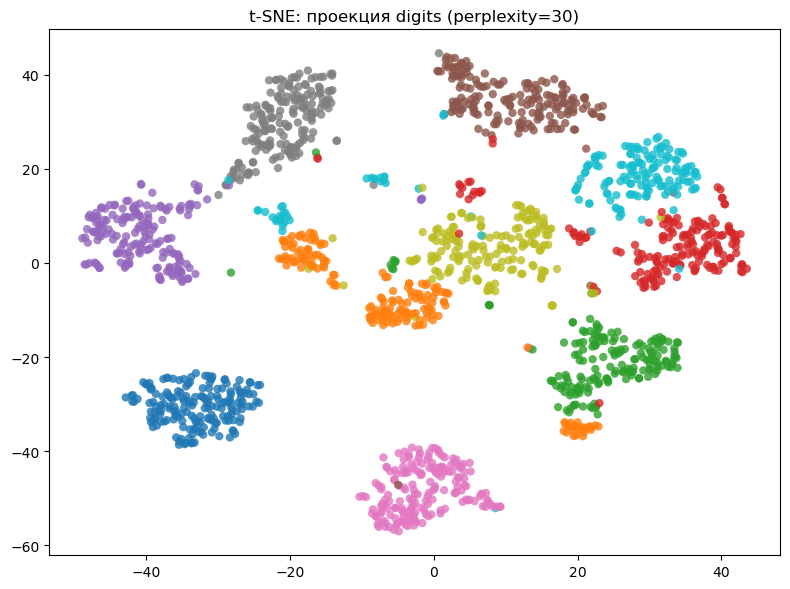

In [30]:
# PCA до 30 компонент (препроцессинг перед t-SNE)
pca_30 = PCA(n_components=30, random_state=42)
X_pca30 = pca_30.fit_transform(X_scaled)
print(f"После PCA(30): {pca_30.explained_variance_ratio_.sum()*100:.1f}% дисперсии")

# t-SNE
tsne = TSNE(n_components=2, perplexity=30, max_iter=1000, random_state=42)
X_tsne = tsne.fit_transform(X_pca30)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=digits.target, cmap='tab10', alpha=0.8, edgecolors='none')
plt.title('t-SNE: проекция digits (perplexity=30)')
plt.tight_layout()
plt.show()

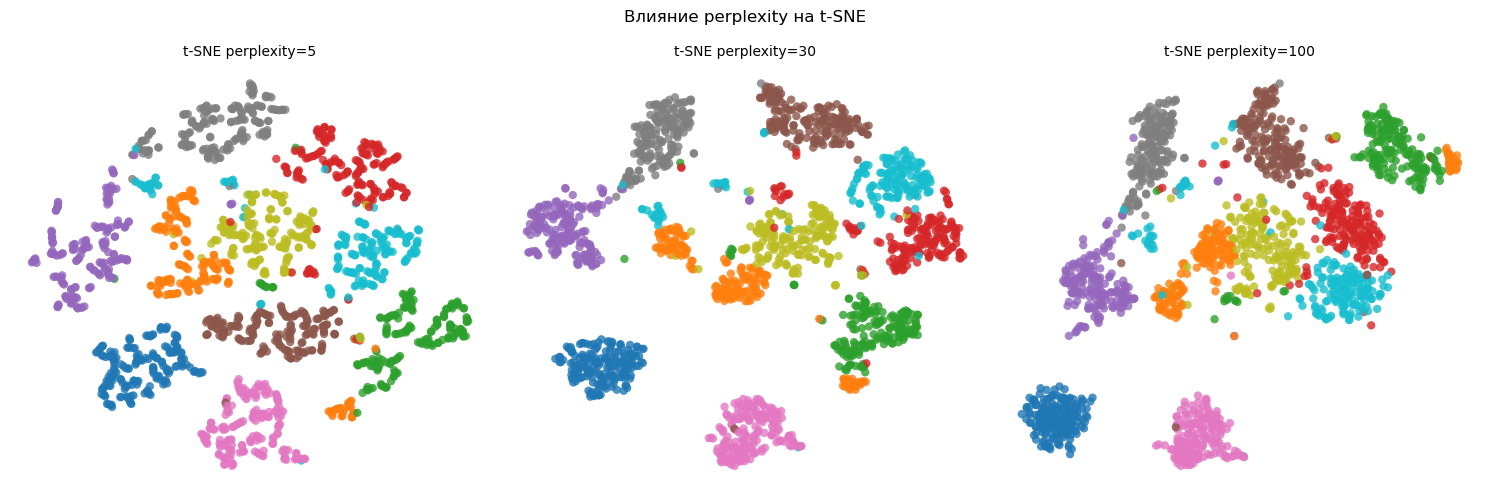

In [32]:
# Эксперимент с perplexity: 5, 30, 100
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, perp in zip(axes, [5, 30, 100]):
    tsne_p = TSNE(n_components=2, perplexity=perp, max_iter=1000, random_state=42)
    # YOUR CODE HERE: fit_transform и scatter
    X_tsne_p = tsne_p.fit_transform(X_pca30)
    scatter = ax.scatter(X_tsne_p[:, 0], X_tsne_p[:, 1], c=digits.target, cmap='tab10', alpha=0.8, edgecolors='none')
    ax.set_title(f"t-SNE perplexity={perp}", fontsize=10)
    ax.axis('off')

plt.suptitle('Влияние perplexity на t-SNE', fontsize=12)
plt.tight_layout()
plt.show()

---
## Шаг 7. UMAP

Если не установлен: `pip install umap-learn`

In [33]:
!pip install umap-learn

umap-learn доступен


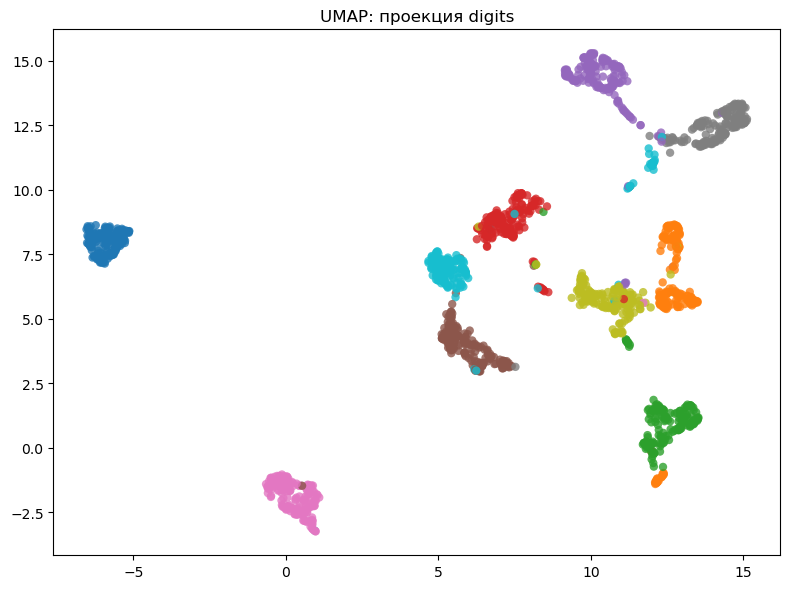

In [35]:
try:
    from umap import UMAP
    UMAP_AVAILABLE = True
    print("umap-learn доступен")
except ImportError:
    print("Установите: pip install umap-learn")
    UMAP_AVAILABLE = False

if UMAP_AVAILABLE:
    reducer = umap.UMAP(n_neighbors=15, min_dist=0.1, random_state=42)
    X_umap = reducer.fit_transform(X_scaled)


    plt.figure(figsize=(8, 6))
    scatter = plt.scatter(X_umap[:, 0], X_umap[:, 1], c=digits.target, cmap='tab10', alpha=0.8, edgecolors='none')
    plt.title('UMAP: проекция digits')
    plt.tight_layout()
    plt.show()

---
## Шаг 8. Сравнение проекций: PCA vs t-SNE vs UMAP

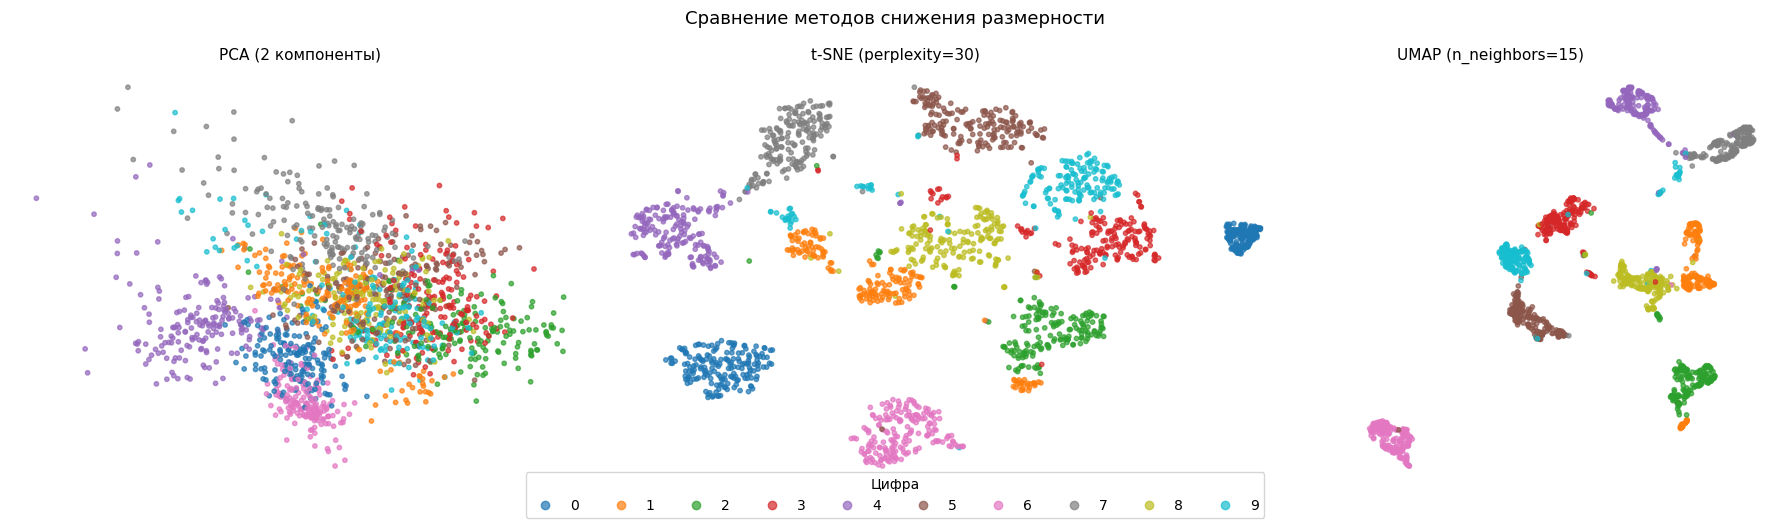

In [36]:
n_plots = 3 if UMAP_AVAILABLE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(6*n_plots, 5))

projections = [
    (X_pca2, 'PCA (2 компоненты)'),
    (X_tsne, 't-SNE (perplexity=30)'),
]
if UMAP_AVAILABLE:
    projections.append((X_umap, 'UMAP (n_neighbors=15)'))

for ax, (X_proj, title) in zip(axes, projections):
    scatter = ax.scatter(X_proj[:, 0], X_proj[:, 1],
                         c=y, cmap='tab10', s=10, alpha=0.7)
    ax.set_title(title, fontsize=11)
    ax.axis('off')

handles, _ = scatter.legend_elements()
fig.legend(handles, [str(i) for i in range(10)],
           loc='lower center', ncol=10, title='Цифра',
           bbox_to_anchor=(0.5, -0.05))
plt.suptitle('Сравнение методов снижения размерности', fontsize=13)
plt.tight_layout()
plt.show()

---
## Шаг 9. Количественная оценка: Silhouette Score

In [38]:
from sklearn.metrics import silhouette_score

scores = {}
scores['PCA (2 компоненты)'] = silhouette_score(X_pca2, y)
scores['t-SNE']              = silhouette_score(X_tsne ,y)
if UMAP_AVAILABLE:
    scores['UMAP']           = silhouette_score(X_umap ,y)

print("Silhouette Score (выше = лучше):")
print("-" * 35)
for name, score in sorted(scores.items(), key=lambda x: -x[1]):
    print(f"{name:25s}: {score:.4f}")

Silhouette Score (выше = лучше):
-----------------------------------
UMAP                     : 0.5777
t-SNE                    : 0.4865
PCA (2 компоненты)       : 0.0547


---
## Шаг 10. Реконструкция из PCA

PCA позволяет восстановить исходные данные через `inverse_transform`. Посмотрим, как выглядит реконструкция при разном числе компонент.

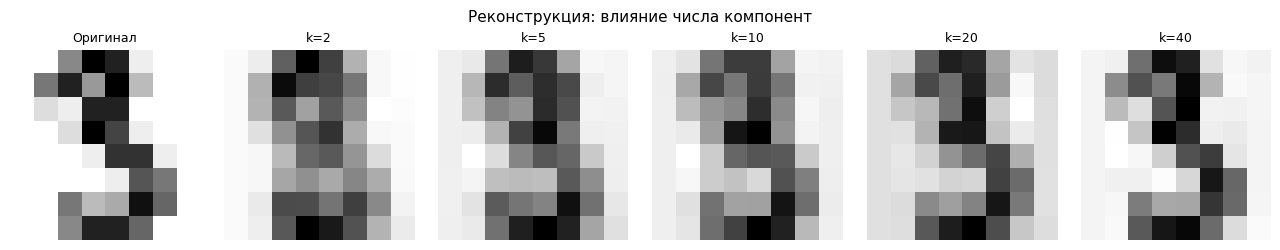

In [42]:
sample_idx = 3
x_original = X_scaled[sample_idx:sample_idx+1]

fig, axes = plt.subplots(1, 6, figsize=(13, 2.5))

# Оригинал
axes[0].imshow(scaler.inverse_transform(x_original).reshape(8, 8), cmap='gray_r')
axes[0].set_title('Оригинал', fontsize=9)
axes[0].axis('off')

for ax, k in zip(axes[1:], [2, 5, 10, 20, 40]):
    pca_k = PCA(n_components=k, random_state=42)
    pca_k.fit(X_scaled)
    # YOUR CODE HERE:
    x_proj = pca_k.transform(x_original)
    x_rec = pca_k.inverse_transform(x_proj)
    X_ne_scaled = scaler.inverse_transform(x_rec)
    # 4. Отобразите как 8x8 изображение
    ax.imshow(X_ne_scaled.reshape(8, 8), cmap='gray_r')
    ax.set_title(f'k={k}', fontsize=9)
    ax.axis('off')

plt.suptitle('Реконструкция: влияние числа компонент', fontsize=11)
plt.tight_layout()
plt.show()

---
## Выводы

### Ваши выводы

**1. Число компонент PCA:**
- Для сохранения 80% дисперсии нужно _21_ компонент из 64.
- Для сохранения 95% дисперсии нужно _40_ компонент из 64.

**2. PCA как препроцессинг:**
- Accuracy без PCA: _0.972_
- Accuracy с PCA (95%): _0.963_
- Accuracy с PCA (80%): _0.947_
- Вывод: _(PCA помогает / не влияет / снижает качество — и почему?)_ В данном случае он по метрике accuracy был хуже, но понятно что он защищает нас от переобучения (вернее, подстраивания под конкретно этот датасет), ведь модель могла сильно зациклиться например на палочке по-середине у цифры "7", а у новой цифры этой палочки могло бы вовсе не быть.

**3. Сравнение проекций:**
- Лучший Silhouette Score: _0.5777_ (метод: _UMAP_)
- Цифры, которые сложнее всего разделить: _1-8,_3-9_

**4. Вывод о методах:**
- _Когда применять PCA, а когда t-SNE/UMAP?_ PCA - когда нужно снизить размерность данных, после чего строить на них модель, особенно если доля обьясняемой дисперсии резко падает после n компоненты. Для визуализации лучше t_SNE/UMAP (сейчас UMAP почти полностью заместил t-SNE, но можно эксперементировать), так как они (впрочем, и только они) лучше находят нелинейные структуры: Луны, Кольца, Спирали и тд.